# Policy-Frame-Titelannotation: LLM-Konsens und Ground-Truth-Abgleich

Dieses Notebook erzeugt belastbare Titelannotationen für den neuen CHN-Headlines-Datensatz.

## Volltext vs. Titel Annotation
Die Ground-Truth-Daten wurden auf Volltexten annotiert. Die Titelannotation wird auf Basis eines LLM-Konsens erstellt und anschließend mit der Volltext-Ground-Truth abgeglichen.

### Schritt 1 Unabhängige Annotation durch LLMs
Die Annotation durch LLMs erfolgt im Single-Shot-Verfahren außerhalb dieses Skripts. Die drei Annotationsdateien werden in diesem Skript geladen.

### Schritt 2 Prüfen des LLM-Konsens
Von den LLMs annotierte Frames werden nur bei mehrheitlicher Übereinstimmung übernommen. Bei drei LLMs gelten 2/3 und 3/3 positive Stimmen als Konsens.

### Schritt 3 Abgleich mit der Volltext-Ground-Truth
Die Konsensdatei wird mit der Ground-Truth-Datei abgeglichen. Frames, die von LLMs im Konsens annotiert wurden, in der Volltext-Ground-Truth jedoch nicht vorkommen, werden gestrichen. Das Notebook erstellt eine abschließende Titel-Annotations-Datei sowie ein Streichungsprotokoll.

### Schritt 4 Frames Statistik
Schließlich wird ausgewertet, welche Frames besonders häufig im Titel erkannt werden (LLM-Konsens) und welche Frames besonders häufig in den Volltexten (Ground Truth) vorkommen.

## Eingabedaten
Das erwartete breite Eingabeformat enthält eine eindeutige Artikel-ID (`Filename`), optionale Metadaten (`Headline_GER`, `Language`) und je eine Spalte pro Policy Frame.

**Umcodierung:** Die Eingabedaten enthalten die Werte `0` (Frame nicht einschlägig), `1` (Frame einschlägig) und `2` (Mainframe). Jeder Wert `2` wird unmittelbar nach der Validierung zu `1` umcodiert. Konsens, Protokolle und Ergebnisdateien arbeiten anschließend ausschließlich mit binären Frame-Werten (`0/1`).

In [7]:
# Standardbibliotheken und in Google Colab vorinstallierte Pakete
from pathlib import Path
from collections import Counter
import json
import math
import re
import shutil
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

print("Pandas:", pd.__version__)

Pandas: 2.3.3


## 1. Konfiguration

Das Notebook liegt im selben Ordner wie die drei LLM-Dateien und die Ground-Truth-Datei. Die Eingaben werden relativ zum aktuellen Notebook-Arbeitsverzeichnis geladen; in Jupyter/Colab sollte das Arbeitsverzeichnis daher der Notebook-Ordner sein. Es gibt keine Upload-Dialoge im Notebook.

In [8]:
# ---------- Eingaben ----------
# Notebook und Eingabedateien liegen im selben Ordner.
# In Jupyter/Colab entspricht Path.cwd() dem Arbeitsverzeichnis des Notebooks,
# sofern das Notebook aus seinem Ordner heraus gestartet wurde.
BASE_DIR = Path.cwd()

LLM_FILES = [
    "chn_headlines_dataset_full_LLM_annotated_claude-sonnet-5.csv",
    "chn_headlines_dataset_full_LLM_annotated_gemini-3.6-flash.csv",
    "chn_headlines_dataset_full_LLM_annotated_GPT-5.6-Luna.csv",
]
GROUND_TRUTH_FILE = "chn_ground_truth_full.csv"

# Lesbare Modellnamen für Protokolle und Statistiken.
LLM_DISPLAY_NAMES = [
    "Claude Sonnet 5",
    "Gemini 3.6 Flash",
    "GPT-5.6 Luna",
]

# Tabellenblatt: 0 = erstes Blatt; bei CSV wird dieser Wert ignoriert.
LLM_SHEET = 0
GROUND_TRUTH_SHEET = 0

# ---------- Schema ----------
LLM_ID_COLUMN = "Filename"
GROUND_TRUTH_ID_COLUMN = "Filename"
ID_COLUMN = "Filename"
TITLE_COLUMN = "Headline_GER"
METADATA_COLUMNS = [TITLE_COLUMN, "Language"]

POLICY_FRAME_COLUMNS = [
    "Economic",
    "Capacity and resources",
    "Morality",
    "Fairness and equality",
    "Legality, constitutionality and jurisprudence",
    "Policy prescription and evaluation",
    "Crime and punishment",
    "Security and defense",
    "Health and safety",
    "Quality of life",
    "Cultural identity",
    "Public opinion",
    "Political",
    "External regulation and reputation",
]

# Bei abweichenden Frame-Namen hier eine eigene Liste einsetzen.
# Mit None werden gemeinsame 0/1/2-Spalten automatisch erkannt.
FRAME_COLUMNS = POLICY_FRAME_COLUMNS

# ---------- Codierung und Regeln ----------
VALUE_RECODE_MAP = {2: 1}

LLM_POSITIVE_VALUES = {1}
LLM_VALID_VALUES = {0, 1, 2}
GROUND_TRUTH_POSITIVE_VALUES = {1}
GROUND_TRUTH_VALID_VALUES = {0, 1, 2}

# Genau drei LLM-Annotationen; 2/3 und 3/3 gelten als Konsens.
REQUIRED_LLM_FILES = 3
MIN_CONSENSUS_VOTES = 2
ACCEPTED_VOTE_COUNTS = set(range(MIN_CONSENSUS_VOTES, REQUIRED_LLM_FILES + 1))

STRICT_LLM_ARTICLE_SET = True
STRICT_GROUND_TRUTH_COVERAGE = True

# ---------- Ausgabe ----------
OUTPUT_DIR = BASE_DIR / "chn_konsens_output"
AUTO_DOWNLOAD_ZIP = True

print("Konfiguration geladen.")


Konfiguration geladen.


## 2. Validierung und Verarbeitung

Die Verarbeitung liest die konfigurierten Dateien direkt aus `/content` ein. Sie bricht bei fehlenden Dateien, doppelten IDs, unbekannten Codes oder fehlenden Pflichtspalten bewusst ab. Dadurch werden stille Zuordnungsfehler vermieden.

In [9]:
def resolve_content_path(filename):
    path = Path(filename)
    return path if path.is_absolute() else BASE_DIR / path


def read_table(path, sheet=0):
    path = Path(path)
    suffix = path.suffix.lower()

    if suffix in {".xlsx", ".xls", ".xlsm"}:
        return pd.read_excel(path, sheet_name=sheet)

    if suffix == ".csv":
        return pd.read_csv(path, sep=";")

    if suffix == ".tsv":
        return pd.read_csv(path, sep="\t")

    raise ValueError(f"Nicht unterstütztes Dateiformat: {path.name}")


if len(LLM_FILES) != REQUIRED_LLM_FILES:
    raise ValueError(
        f"Für den konfigurierten Konsens werden genau {REQUIRED_LLM_FILES} "
        f"LLM-Dateien benötigt; eingetragen: {len(LLM_FILES)}"
    )

llm_paths = [resolve_content_path(filename) for filename in LLM_FILES]
ground_truth_path = resolve_content_path(GROUND_TRUTH_FILE)
missing = [str(path) for path in [*llm_paths, ground_truth_path] if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Diese Dateien fehlen im Notebook-/Arbeitsverzeichnis: " + ", ".join(missing)
    )

print(f"Eingabedateien aus {BASE_DIR}:")
for path in llm_paths:
    print(" - LLM:", path)
print(" - Ground Truth:", ground_truth_path)


def normalized_code(value):
    # Vereinheitlicht Zahlen- und Textcodes für robuste Vergleiche.
    if pd.isna(value):
        return None
    if isinstance(value, (bool, np.bool_)):
        return "1" if bool(value) else "0"
    if isinstance(value, (int, np.integer)):
        return str(int(value))
    if isinstance(value, (float, np.floating)) and float(value).is_integer():
        return str(int(value))
    return unicodedata.normalize("NFKC", str(value)).strip().casefold()


def normalized_set(values):
    return {normalized_code(v) for v in values}


def positive_mask(series, positive_values):
    positive = normalized_set(positive_values)
    return series.map(normalized_code).isin(positive)


def recode_frame_values(df, frame_columns, recode_map):
    # Codiert konfigurierte Werte in allen Frame-Spalten um (hier: 2 -> 1).
    normalized_map = {normalized_code(k): v for k, v in recode_map.items()}
    result = df.copy()
    for frame in frame_columns:
        result[frame] = result[frame].map(
            lambda value: normalized_map.get(normalized_code(value), value)
            if not pd.isna(value) else value
        )
    return result


def normalized_column_name(value):
    # Ignoriert Groß-/Kleinschreibung und Satzzeichen, nicht aber Wörter.
    text = unicodedata.normalize("NFKC", str(value)).casefold().strip()
    return " ".join(re.findall(r"\w+", text, flags=re.UNICODE))


def resolve_column_name(columns, requested, source_name):
    if requested in columns:
        return requested
    key = normalized_column_name(requested)
    matches = [col for col in columns if normalized_column_name(col) == key]
    if len(matches) == 1:
        return matches[0]
    if len(matches) > 1:
        raise ValueError(
            f"{source_name}: Spalte '{requested}' ist nicht eindeutig zuordenbar: {matches}"
        )
    return None


schema_resolution_records = []


def validate_and_prepare(
    df, source_name, source_id_column, frame_columns, valid_values
):
    df = df.copy()
    rename_map = {}

    resolved_id = resolve_column_name(df.columns, source_id_column, source_name)
    if resolved_id is None:
        raise ValueError(
            f"{source_name}: ID-Spalte '{source_id_column}' fehlt. "
            f"Vorhandene Spalten: {list(df.columns)}"
        )
    rename_map[resolved_id] = ID_COLUMN
    schema_resolution_records.append({
        "Datei": source_name,
        "Typ": "ID",
        "Quellspalte": resolved_id,
        "Interne_Spalte": ID_COLUMN,
    })

    missing = []
    for frame in frame_columns:
        resolved_frame = resolve_column_name(df.columns, frame, source_name)
        if resolved_frame is None:
            missing.append(frame)
        else:
            rename_map[resolved_frame] = frame
            schema_resolution_records.append({
                "Datei": source_name,
                "Typ": "Frame",
                "Quellspalte": resolved_frame,
                "Interne_Spalte": frame,
            })
    if missing:
        raise ValueError(
            f"{source_name}: Frame-Spalten fehlen oder konnten nicht zugeordnet werden: {missing}"
        )

    df = df.rename(columns=rename_map)

    if df[ID_COLUMN].isna().any():
        rows = (df.index[df[ID_COLUMN].isna()] + 2).tolist()[:10]
        raise ValueError(f"{source_name}: leere Artikel-ID in Excel-Zeile(n) {rows}")

    df[ID_COLUMN] = df[ID_COLUMN].astype(str).str.strip()
    duplicates = df.loc[df[ID_COLUMN].duplicated(keep=False), ID_COLUMN].unique().tolist()
    if duplicates:
        raise ValueError(f"{source_name}: doppelte Artikel-IDs, z. B. {duplicates[:10]}")

    allowed = normalized_set(valid_values)
    invalid_report = {}
    for frame in frame_columns:
        observed = {normalized_code(v) for v in df[frame].dropna().unique()}
        invalid = sorted(v for v in observed if v not in allowed)
        if invalid:
            invalid_report[frame] = invalid[:10]
    if invalid_report:
        raise ValueError(
            f"{source_name}: unbekannte Frame-Codes. "
            f"Gültige Codes sind {sorted(allowed)}. Details: {invalid_report}"
        )
    return recode_frame_values(df, frame_columns, VALUE_RECODE_MAP)


def auto_detect_frames(llm_frames):
    common = set(llm_frames[0].columns)
    for df in llm_frames[1:]:
        common &= set(df.columns)
    excluded = {ID_COLUMN, LLM_ID_COLUMN, GROUND_TRUTH_ID_COLUMN, *METADATA_COLUMNS}
    allowed = normalized_set(LLM_VALID_VALUES)
    detected = []
    # Reihenfolge der ersten LLM-Datei beibehalten
    for col in llm_frames[0].columns:
        if col in excluded or col not in common:
            continue
        ok = True
        for df in llm_frames:
            observed = {normalized_code(v) for v in df[col].dropna().unique()}
            if not observed.issubset(allowed):
                ok = False
                break
        if ok:
            detected.append(col)
    if not detected:
        raise ValueError("Es konnten keine gemeinsamen Frame-Spalten erkannt werden.")
    return detected


llm_raw = [read_table(path, LLM_SHEET) for path in llm_paths]
ground_truth_raw = read_table(ground_truth_path, GROUND_TRUTH_SHEET)

frame_columns = list(FRAME_COLUMNS) if FRAME_COLUMNS is not None else auto_detect_frames(llm_raw)
llm_data = [
    validate_and_prepare(
        df, path.name, LLM_ID_COLUMN, frame_columns, LLM_VALID_VALUES
    )
    for df, path in zip(llm_raw, llm_paths)
]
ground_truth = validate_and_prepare(
    ground_truth_raw,
    ground_truth_path.name,
    GROUND_TRUTH_ID_COLUMN,
    frame_columns,
    GROUND_TRUTH_VALID_VALUES,
)

if TITLE_COLUMN not in llm_data[0].columns:
    raise ValueError(
        f"{llm_paths[0].name}: Titelspalte '{TITLE_COLUMN}' fehlt. "
        "Sie wird für die Ausgabedateien benötigt."
    )

schema_resolution = pd.DataFrame(schema_resolution_records)

print(f"Erkannte/verwendete Frames: {len(frame_columns)}")
print(f"ID-Abgleich: LLM '{LLM_ID_COLUMN}' <-> Ground Truth '{GROUND_TRUTH_ID_COLUMN}'")
display(pd.DataFrame({"Frame": frame_columns}))

Eingabedateien aus /Users/Familie/Documents/Uni_Regensburg/A_Digital_Humanities/2SE_SS26/Natural_Language_Engineering/projekt/frame_detect_NLP/Y_additional_dataset/5_konsens_bildung/chn:
 - LLM: /Users/Familie/Documents/Uni_Regensburg/A_Digital_Humanities/2SE_SS26/Natural_Language_Engineering/projekt/frame_detect_NLP/Y_additional_dataset/5_konsens_bildung/chn/chn_headlines_dataset_full_LLM_annotated_claude-sonnet-5.csv
 - LLM: /Users/Familie/Documents/Uni_Regensburg/A_Digital_Humanities/2SE_SS26/Natural_Language_Engineering/projekt/frame_detect_NLP/Y_additional_dataset/5_konsens_bildung/chn/chn_headlines_dataset_full_LLM_annotated_gemini-3.6-flash.csv
 - LLM: /Users/Familie/Documents/Uni_Regensburg/A_Digital_Humanities/2SE_SS26/Natural_Language_Engineering/projekt/frame_detect_NLP/Y_additional_dataset/5_konsens_bildung/chn/chn_headlines_dataset_full_LLM_annotated_GPT-5.6-Luna.csv
 - Ground Truth: /Users/Familie/Documents/Uni_Regensburg/A_Digital_Humanities/2SE_SS26/Natural_Language_Eng

,Frame
0,Economic
1,Capacity and resources
2,Morality
3,Fairness and equality
4,"Legality, constitutionality and jurisprudence"
5,Policy prescription and evaluation
6,Crime and punishment
7,Security and defense
8,Health and safety
9,Quality of life


## 3. LLM-Konsens berechnen

Die LLM-Dateien werden über `Filename`, die Ground Truth über `article id` identifiziert. Beide Spalten werden intern auf dieselbe Artikel-ID vereinheitlicht. Die Zeilenposition spielt keine Rolle. Fehlende oder zusätzliche IDs werden im Prüfbericht sichtbar; in der strikten Standardeinstellung führen sie zum Abbruch.

In [10]:
llm_names = list(LLM_DISPLAY_NAMES)
if len(llm_names) != len(llm_paths):
    raise ValueError(
        "LLM_DISPLAY_NAMES und LLM_FILES müssen gleich viele Einträge enthalten."
    )

id_lists = [df[ID_COLUMN].tolist() for df in llm_data]
id_sets = [set(ids) for ids in id_lists]
reference_ids = id_lists[0]
common_ids = set.intersection(*id_sets)
union_ids = set.union(*id_sets)

article_set_report = pd.DataFrame({
    "Datei": [p.name for p in llm_paths],
    "Artikel": [len(s) for s in id_sets],
    "Fehlen_gegenüber_Union": [len(union_ids - s) for s in id_sets],
    "Zusätzlich_gegenüber_Schnittmenge": [len(s - common_ids) for s in id_sets],
})

if STRICT_LLM_ARTICLE_SET and any(s != id_sets[0] for s in id_sets[1:]):
    examples = {
        llm_paths[i].name: sorted(list(union_ids - id_sets[i]))[:10]
        for i in range(len(id_sets))
        if union_ids - id_sets[i]
    }
    raise ValueError(
        "Die LLM-Dateien enthalten nicht dieselben Artikel-IDs. "
        f"Beispiele fehlender IDs: {examples}. "
        "Fehler beheben oder STRICT_LLM_ARTICLE_SET=False setzen."
    )

# Bei nicht-strikter Verarbeitung wird transparent nur die Schnittmenge genutzt.
article_ids = [article_id for article_id in reference_ids if article_id in common_ids]
if not article_ids:
    raise ValueError("Die LLM-Dateien haben keine gemeinsamen Artikel-IDs.")

llm_indexed = [df.set_index(ID_COLUMN).loc[article_ids] for df in llm_data]

# Metadaten und insbesondere der Titel stammen aus der ersten LLM-Datei.
available_metadata = [c for c in METADATA_COLUMNS if c in llm_indexed[0].columns]
base_data = llm_indexed[0][available_metadata].copy() if available_metadata else pd.DataFrame(index=article_ids)
base_data.index.name = ID_COLUMN
title_lookup = base_data[TITLE_COLUMN].to_dict()

metadata_mismatch_records = []
for metadata_col in available_metadata:
    ref = llm_indexed[0][metadata_col].fillna("").astype(str)
    for model_idx in range(1, len(llm_indexed)):
        if metadata_col not in llm_indexed[model_idx].columns:
            continue
        other = llm_indexed[model_idx][metadata_col].fillna("").astype(str)
        mismatch = ref.ne(other)
        for article_id in mismatch[mismatch].index[:100]:
            metadata_mismatch_records.append({
                ID_COLUMN: article_id,
                "Spalte": metadata_col,
                "Referenzdatei": llm_paths[0].name,
                "Vergleichsdatei": llm_paths[model_idx].name,
                "Referenzwert": ref.loc[article_id],
                "Vergleichswert": other.loc[article_id],
            })
metadata_mismatches = pd.DataFrame(metadata_mismatch_records)

vote_counts = pd.DataFrame(index=article_ids)
consensus_binary = pd.DataFrame(index=article_ids)
protocol_records = []

for frame in frame_columns:
    raw_series = [df[frame] for df in llm_indexed]
    positive_series = [positive_mask(s, LLM_POSITIVE_VALUES) for s in raw_series]
    votes = sum(s.astype(int) for s in positive_series)
    accepted = votes.isin(ACCEPTED_VOTE_COUNTS)
    vote_counts[frame] = votes.astype(int)
    consensus_binary[frame] = accepted.astype(int)

    for pos, article_id in enumerate(article_ids):
        vote_count = int(votes.iloc[pos])
        row = {
            ID_COLUMN: article_id,
            TITLE_COLUMN: title_lookup.get(article_id, ""),
            "Frame": frame,
            "Positive_Stimmen": vote_count,
            "Übereinstimmung": f"{vote_count}/{REQUIRED_LLM_FILES}",
            "Konsens_übernommen": int(vote_count in ACCEPTED_VOTE_COUNTS),
            "Konsensstatus": (
                f"übernommen ({vote_count}/{REQUIRED_LLM_FILES})"
                if vote_count in ACCEPTED_VOTE_COUNTS
                else f"nicht übernommen ({vote_count}/{REQUIRED_LLM_FILES})"
            ),
        }
        for model_name, raw, pos_mask in zip(llm_names, raw_series, positive_series):
            row[f"Binärwert_{model_name}"] = raw.iloc[pos]
            row[f"Positiv_{model_name}"] = int(pos_mask.iloc[pos])
        protocol_records.append(row)

consensus_protocol = pd.DataFrame(protocol_records)
consensus_wide = base_data.join(consensus_binary).reset_index()
consensus_positive_long = consensus_protocol.loc[
    consensus_protocol["Konsens_übernommen"].eq(1)
].copy()

print(f"Verarbeitete Artikel: {len(article_ids):,}".replace(",", "."))
print("Positive Artikel-Frame-Paare im LLM-Konsens:", int(consensus_binary.to_numpy().sum()))
display(article_set_report)
display(consensus_positive_long.head(10))

Verarbeitete Artikel: 312
Positive Artikel-Frame-Paare im LLM-Konsens: 680


,Datei,Artikel,Fehlen_gegenüber_Union,Zusätzlich_gegenüber_Schnittmenge
0,chn_headlines_dataset_full_LLM_annotated_claude-sonnet-5.csv,312,0,0
1,chn_headlines_dataset_full_LLM_annotated_gemini-3.6-flash.csv,312,0,0
2,chn_headlines_dataset_full_LLM_annotated_GPT-5.6-Luna.csv,312,0,0


,Filename,Headline_GER,Frame,Positive_Stimmen,Übereinstimmung,Konsens_übernommen,Konsensstatus,Binärwert_Claude Sonnet 5,Positiv_Claude Sonnet 5,Binärwert_Gemini 3.6 Flash,Positiv_Gemini 3.6 Flash,Binärwert_GPT-5.6 Luna,Positiv_GPT-5.6 Luna
20,chn_21,Die japanische Fabrik von TSMC wird voraussichtlich im Oktober mit der Installation beginnen und Ende nächsten Jahre...,Economic,3,3/3,1,übernommen (3/3),1,1,1,1,1,1
26,chn_27,S&P stuft die Kreditwürdigkeit Russlands angesichts des Krieges zwischen Russland und der Ukraine auf „Junk“ herab,Economic,3,3/3,1,übernommen (3/3),1,1,1,1,1,1
34,chn_35,Das Vereinigte Königreich und die EU leiten gleichzeitig kartellrechtliche Ermittlungen gegen Facebook ein,Economic,2,2/3,1,übernommen (2/3),1,1,1,1,0,0
38,chn_39,Das Gesamtwachstum der Einzelhandelsumsätze in China erreichte im Oktober dieses Jahres einen neuen Höchststand,Economic,3,3/3,1,übernommen (3/3),1,1,1,1,1,1
45,chn_46,Die US-Beschränkungen für den Export von Chip-Werkzeugen nach China stehen kurz vor dem Abschluss,Economic,3,3/3,1,übernommen (3/3),1,1,1,1,1,1
54,chn_55,Chinas Fertigungsindustrie hat im September Fahrt aufgenommen,Economic,3,3/3,1,übernommen (3/3),1,1,1,1,1,1
55,chn_56,320 glückliche Unternehmen wurden mit Gold ausgezeichnet. Manpower Bank: Fast 60 % der Büroangestellten sind der Mei...,Economic,2,2/3,1,übernommen (2/3),0,0,1,1,1,1
56,chn_57,"Russland plant, Schulden für behinderte Soldaten zu begleichen",Economic,3,3/3,1,übernommen (3/3),1,1,1,1,1,1
73,chn_74,"Der CEO von Goldman Sachs warnt: Eine hartnäckige Inflation könnte die Fed dazu zwingen, die Zinsen weiter anzuheben",Economic,3,3/3,1,übernommen (3/3),1,1,1,1,1,1
76,chn_77,Jugendliche aus Los Angeles County können bezahlte Praktikumsmöglichkeiten bei staatlichen und privaten Unternehmen ...,Economic,3,3/3,1,übernommen (3/3),1,1,1,1,1,1


## 4. Abgleich mit der SemEval-Volltextannotation

Ein LLM-Konsens-Frame wird nur dann als Titelannotation behalten, wenn derselbe Frame in der SemEval-Zeile des Artikels positiv codiert ist.

In [11]:
gt_indexed_all = ground_truth.set_index(ID_COLUMN)
gt_ids = set(gt_indexed_all.index)
missing_in_gt = [article_id for article_id in article_ids if article_id not in gt_ids]

if STRICT_GROUND_TRUTH_COVERAGE and missing_in_gt:
    raise ValueError(
        f"Für {len(missing_in_gt)} LLM-annotierte Artikel fehlt die Ground Truth, "
        f"z. B. {missing_in_gt[:10]}."
    )

# Fehlende Ground-Truth-Zeilen werden nur im nicht-strikten Modus als nicht positiv behandelt.
gt_indexed = gt_indexed_all.reindex(article_ids)
gt_binary = pd.DataFrame(index=article_ids)
for frame in frame_columns:
    gt_binary[frame] = positive_mask(gt_indexed[frame], GROUND_TRUTH_POSITIVE_VALUES).astype(int)

final_binary = (consensus_binary.astype(bool) & gt_binary.astype(bool)).astype(int)
removed_binary = (consensus_binary.astype(bool) & ~gt_binary.astype(bool)).astype(int)
final_wide = base_data.join(final_binary).reset_index()

final_long_records = []
removal_records = []
protocol_lookup = consensus_protocol.set_index([ID_COLUMN, "Frame"])
for frame in frame_columns:
    for article_id in article_ids:
        if final_binary.at[article_id, frame] == 1:
            final_long_records.append({
                ID_COLUMN: article_id,
                TITLE_COLUMN: title_lookup.get(article_id, ""),
                "Frame": frame,
                "Titelannotation": 1,
            })
        if removed_binary.at[article_id, frame] == 1:
            protocol_row = protocol_lookup.loc[(article_id, frame)]
            record = {
                ID_COLUMN: article_id,
                TITLE_COLUMN: title_lookup.get(article_id, ""),
                "Frame": frame,
                "Positive_Stimmen": int(protocol_row["Positive_Stimmen"]),
                "Übereinstimmung": protocol_row["Übereinstimmung"],
                "Ground Truth_Binärwert": gt_indexed.at[article_id, frame] if article_id in gt_ids else np.nan,
                "Grund": (
                    "Artikel fehlt in der Ground-Truth-Datei"
                    if article_id not in gt_ids
                    else "LLM-Konsens vorhanden, Frame fehlt in der Ground Truth-Volltextannotation"
                ),
            }
            for model_name in llm_names:
                record[f"Binärwert_{model_name}"] = protocol_row[f"Binärwert_{model_name}"]
            removal_records.append(record)

final_long = pd.DataFrame(
    final_long_records, columns=[ID_COLUMN, TITLE_COLUMN, "Frame", "Titelannotation"]
)
removal_protocol = pd.DataFrame(
    removal_records,
    columns=[
        ID_COLUMN, TITLE_COLUMN, "Frame", "Positive_Stimmen", "Übereinstimmung", "Ground Truth_Binärwert",
        "Grund", *[f"Binärwert_{name}" for name in llm_names]
    ],
)

print("Nach Ground Truth-Abgleich verbliebene Artikel-Frame-Paare:", int(final_binary.to_numpy().sum()))
print("Gestrichene Artikel-Frame-Paare:", int(removed_binary.to_numpy().sum()))
display(removal_protocol.head(10))

Nach Ground Truth-Abgleich verbliebene Artikel-Frame-Paare: 467
Gestrichene Artikel-Frame-Paare: 213


,Filename,Headline_GER,Frame,Positive_Stimmen,Übereinstimmung,Ground Truth_Binärwert,Grund,Binärwert_Claude Sonnet 5,Binärwert_Gemini 3.6 Flash,Binärwert_GPT-5.6 Luna
0,chn_35,Das Vereinigte Königreich und die EU leiten gleichzeitig kartellrechtliche Ermittlungen gegen Facebook ein,Economic,2,2/3,0,"LLM-Konsens vorhanden, Frame fehlt in der Ground Truth-Volltextannotation",1,1,0
1,chn_46,Die US-Beschränkungen für den Export von Chip-Werkzeugen nach China stehen kurz vor dem Abschluss,Economic,3,3/3,0,"LLM-Konsens vorhanden, Frame fehlt in der Ground Truth-Volltextannotation",1,1,1
2,chn_117,"Der Iran plante, 1 Million Barrel Öl nach China zu schmuggeln, wurde jedoch von den Vereinigten Staaten beschlagnahmt",Economic,2,2/3,0,"LLM-Konsens vorhanden, Frame fehlt in der Ground Truth-Volltextannotation",1,1,0
3,chn_118,Huawei und SMIC erhielten innerhalb eines halben Jahres jeweils zweistellige Milliardenbeträge an US-amerikanischen ...,Economic,3,3/3,0,"LLM-Konsens vorhanden, Frame fehlt in der Ground Truth-Volltextannotation",1,1,1
4,chn_123,Überprüfung der Lieferkette: US-Handelsministerium stellt Vorladung an ein chinesisches Unternehmen aus,Economic,2,2/3,0,"LLM-Konsens vorhanden, Frame fehlt in der Ground Truth-Volltextannotation",1,1,0
5,chn_127,"Taiwans MediaTek beantragt bei der US-Regierung, Huawei weiterhin zu beliefern",Economic,3,3/3,0,"LLM-Konsens vorhanden, Frame fehlt in der Ground Truth-Volltextannotation",1,1,1
6,chn_182,Die Biden-Regierung weitet die gegen China verhängten Chipkontrollen auf Macau aus,Economic,2,2/3,0,"LLM-Konsens vorhanden, Frame fehlt in der Ground Truth-Volltextannotation",1,1,0
7,chn_183,Taiwans im Inland hergestellte U-Boot-Ausrüstung der „Roten Zone“ erhält Exportlizenz von den Vereinigten Staaten,Economic,2,2/3,0,"LLM-Konsens vorhanden, Frame fehlt in der Ground Truth-Volltextannotation",0,1,1
8,chn_238,Wang Youming: Erhöhen Sie die grenzüberschreitende Integration der roten Kulturindustrie und anderer Branchen,Economic,3,3/3,0,"LLM-Konsens vorhanden, Frame fehlt in der Ground Truth-Volltextannotation",1,1,1
9,chn_245,Das Ministerium für Kultur und Tourismus hat eine Mitteilung herausgegeben: „Förderung der gesunden Entwicklung des ...,Economic,2,2/3,0,"LLM-Konsens vorhanden, Frame fehlt in der Ground Truth-Volltextannotation",1,1,0


## 5. Frame-Statistik

Verglichen werden LLM-Konsens auf Titelebene, SemEval-Volltextannotation und die finale Titelannotation. Zusätzlich werden 3/4- und 4/4-Konsens sowie die Häufigkeiten je einzelnem LLM ausgewiesen.

,Frame,LLM_Konsens_Titel_n,LLM_Konsens_Titel_%,davon_2_von_3_n,davon_3_von_3_n,SemEval_Volltext_n,SemEval_Volltext_%,Finale_Titelannotation_n,Finale_Titelannotation_%,Gestrichen_n,Beibehaltungsquote_%,Titelsichtbarkeit_vs_SemEval_%,Anteil_an_finalen_Annotationen_%
0,External regulation and reputation,109,0.349359,37,72,112,0.358974,97,0.310897,12,0.889908,0.866071,0.207709
1,Political,107,0.342949,54,53,39,0.125000,32,0.102564,75,0.299065,0.820513,0.068522
2,Policy prescription and evaluation,65,0.208333,43,22,144,0.461538,55,0.176282,10,0.846154,0.381944,0.117773
3,Economic,61,0.195513,17,44,86,0.275641,49,0.157051,12,0.803279,0.569767,0.104925
4,Health and safety,61,0.195513,15,46,54,0.173077,40,0.128205,21,0.655738,0.740741,0.085653
5,Security and defense,60,0.192308,22,38,102,0.326923,51,0.163462,9,0.850000,0.500000,0.109208
6,Crime and punishment,45,0.144231,11,34,77,0.246795,40,0.128205,5,0.888889,0.519481,0.085653
7,Cultural identity,41,0.131410,9,32,38,0.121795,25,0.080128,16,0.609756,0.657895,0.053533
8,"Legality, constitutionality and jurisprudence",34,0.108974,18,16,66,0.211538,9,0.028846,25,0.264706,0.136364,0.019272
9,Fairness and equality,28,0.089744,10,18,39,0.125000,15,0.048077,13,0.535714,0.384615,0.032120


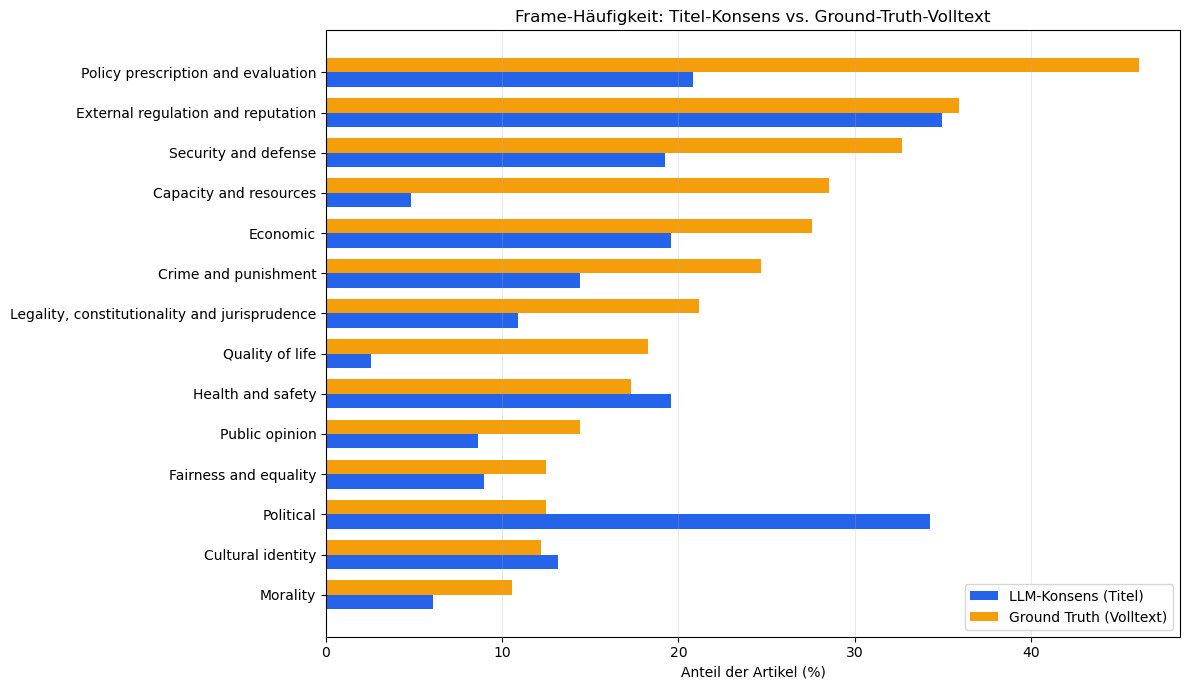

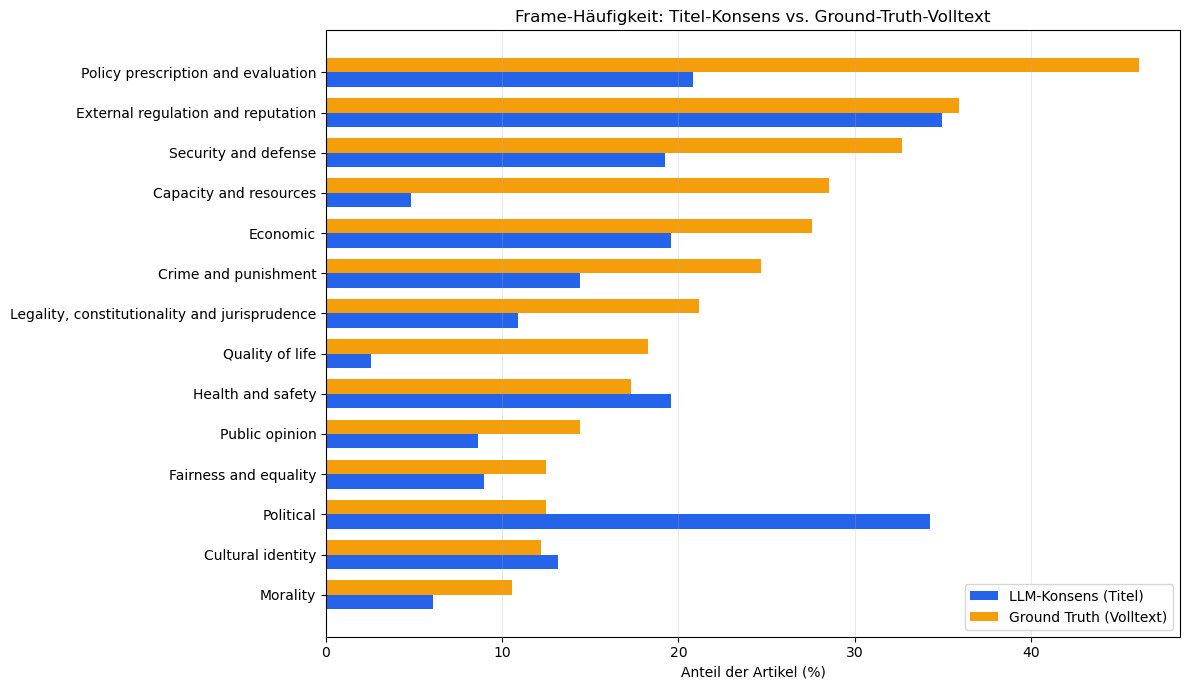

In [12]:
n_articles = len(article_ids)
total_final_annotations = int(final_binary.to_numpy().sum())
stats_records = []
for frame in frame_columns:
    title_count = int(consensus_binary[frame].sum())
    fulltext_count = int(gt_binary[frame].sum())
    final_count = int(final_binary[frame].sum())
    removed_count = int(removed_binary[frame].sum())
    record = {
        "Frame": frame,
        "LLM_Konsens_Titel_n": title_count,
        "LLM_Konsens_Titel_%": title_count / n_articles if n_articles else np.nan,
    }
    for vote_count in sorted(ACCEPTED_VOTE_COUNTS):
        record[f"davon_{vote_count}_von_{REQUIRED_LLM_FILES}_n"] = int(
            vote_counts[frame].eq(vote_count).sum()
        )
    record.update({
        "SemEval_Volltext_n": fulltext_count,
        "SemEval_Volltext_%": fulltext_count / n_articles if n_articles else np.nan,
        "Finale_Titelannotation_n": final_count,
        "Finale_Titelannotation_%": final_count / n_articles if n_articles else np.nan,
        "Gestrichen_n": removed_count,
        "Beibehaltungsquote_%": final_count / title_count if title_count else np.nan,
        "Titelsichtbarkeit_vs_SemEval_%": final_count / fulltext_count if fulltext_count else np.nan,
        "Anteil_an_finalen_Annotationen_%": (
            final_count / total_final_annotations if total_final_annotations else np.nan
        ),
    })
    stats_records.append(record)

frame_statistics = pd.DataFrame(stats_records).sort_values(
    ["LLM_Konsens_Titel_n", "SemEval_Volltext_n"], ascending=False
).reset_index(drop=True)

per_llm_records = []
for model_name, indexed_df in zip(llm_names, llm_indexed):
    for frame in frame_columns:
        count = int(positive_mask(indexed_df[frame], LLM_POSITIVE_VALUES).sum())
        per_llm_records.append({
            "LLM": model_name,
            "Frame": frame,
            "Positiv_n": count,
            "Positiv_%": count / n_articles if n_articles else np.nan,
        })
per_llm_statistics = pd.DataFrame(per_llm_records)

display(frame_statistics)

plot_data = frame_statistics.sort_values("SemEval_Volltext_%", ascending=True)
y = np.arange(len(plot_data))
height = 0.36
fig, ax = plt.subplots(figsize=(12, max(6, len(plot_data) * 0.5)))
ax.barh(y - height/2, plot_data["LLM_Konsens_Titel_%"] * 100, height,
        label="LLM-Konsens (Titel)", color="#2563EB")
ax.barh(y + height/2, plot_data["SemEval_Volltext_%"] * 100, height,
        label="Ground Truth (Volltext)", color="#F59E0B")
ax.set_yticks(y, plot_data["Frame"])
ax.set_xlabel("Anteil der Artikel (%)")
ax.set_title("Frame-Häufigkeit: Titel-Konsens vs. Ground-Truth-Volltext")
ax.grid(axis="x", alpha=0.25)
ax.legend()
fig.tight_layout()
display(fig)

## 6. Dateien schreiben und herunterladen

Die Excel-Dateien werden mit `openpyxl` geschrieben; `xlsxwriter` wird nicht benötigt. Sie erhalten Filter, eingefrorene Kopfzeilen, lesbare Spaltenbreiten und Prozentformate. Zusätzlich wird ein ZIP mit allen Ergebnissen erstellt.

In [13]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
chart_path = OUTPUT_DIR / "chn_05_frame_statistik.png"
fig.savefig(chart_path, dpi=180, bbox_inches="tight")


def safe_excel_value(value):
    if isinstance(value, (list, tuple, set, dict)):
        return json.dumps(value, ensure_ascii=False)
    return value


from openpyxl.styles import Alignment, Border, Font, PatternFill, Side
from openpyxl.utils import get_column_letter
from openpyxl.drawing.image import Image as OpenpyxlImage


def write_formatted_workbook(path, sheets, percent_columns=None, image_sheet=None, image_path=None):
    percent_columns = percent_columns or {}
    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        for sheet_name, df in sheets.items():
            clean = df.copy()
            for col in clean.columns:
                if clean[col].dtype == "object":
                    clean[col] = clean[col].map(safe_excel_value)
            clean.to_excel(writer, sheet_name=sheet_name, index=False)
            ws = writer.sheets[sheet_name]
            ws.freeze_panes = "B2"
            ws.row_dimensions[1].height = 32

            header_fill = PatternFill("solid", fgColor="1F4E78")
            header_font = Font(bold=True, color="FFFFFF")
            header_alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
            thin_side = Side(style="thin", color="D9E1F2")
            header_border = Border(left=thin_side, right=thin_side, top=thin_side, bottom=thin_side)

            if len(clean.columns) > 0:
                last_col = get_column_letter(len(clean.columns))
                last_row = max(len(clean) + 1, 1)
                ws.auto_filter.ref = f"A1:{last_col}{last_row}"
                for cell in ws[1]:
                    cell.fill = header_fill
                    cell.font = header_font
                    cell.alignment = header_alignment
                    cell.border = header_border

            for col_idx, col in enumerate(clean.columns):
                sample = clean[col].dropna().astype(str).head(500)
                max_len = max([len(str(col)), *sample.map(len).tolist()] or [len(str(col))])
                width = min(max(max_len + 2, 10), 45)
                excel_col = get_column_letter(col_idx + 1)
                ws.column_dimensions[excel_col].width = width

                number_format = "0.0%" if col in percent_columns.get(sheet_name, []) else None
                if col.endswith("_n") or col in {"Positive_Stimmen", "Konsens_übernommen", "Titelannotation"}:
                    number_format = "0"
                if number_format is not None:
                    for row_idx in range(2, len(clean) + 2):
                        ws.cell(row=row_idx, column=col_idx + 1).number_format = number_format

            if image_path is not None and image_sheet == sheet_name:
                image = OpenpyxlImage(str(image_path))
                image.width = int(image.width * 0.62)
                image.height = int(image.height * 0.62)
                insert_col = min(len(clean.columns) + 3, 15)
                ws.add_image(image, f"{get_column_letter(insert_col)}2")


validation_summary = pd.DataFrame([
    {"Prüfung": "Anzahl LLM-Dateien", "Ergebnis": len(llm_paths), "Status": "OK"},
    {"Prüfung": "Verarbeitete Artikel", "Ergebnis": len(article_ids), "Status": "OK"},
    {"Prüfung": "Frame-Spalten", "Ergebnis": len(frame_columns), "Status": "OK"},
    {"Prüfung": "Titelspalte in Ausgabe", "Ergebnis": TITLE_COLUMN,
     "Status": "OK" if TITLE_COLUMN in base_data.columns else "Fehler"},
    {"Prüfung": "LLM-ID-Sets identisch", "Ergebnis": all(s == id_sets[0] for s in id_sets),
     "Status": "OK" if all(s == id_sets[0] for s in id_sets) else "Hinweis"},
    {"Prüfung": "Artikel ohne Ground Truth", "Ergebnis": len(missing_in_gt),
     "Status": "OK" if not missing_in_gt else "Hinweis"},
    {"Prüfung": "Metadaten-Abweichungen (max. 100 je Vergleich protokolliert)",
     "Ergebnis": len(metadata_mismatches), "Status": "OK" if metadata_mismatches.empty else "Hinweis"},
])

config_table = pd.DataFrame([
    {"Parameter": "LLM_ID_COLUMN", "Wert": LLM_ID_COLUMN},
    {"Parameter": "GROUND_TRUTH_ID_COLUMN", "Wert": GROUND_TRUTH_ID_COLUMN},
    {"Parameter": "ID_COLUMN_intern_und_Ausgabe", "Wert": ID_COLUMN},
    {"Parameter": "TITLE_COLUMN", "Wert": TITLE_COLUMN},
    {"Parameter": "FRAME_COLUMNS", "Wert": frame_columns},
    {"Parameter": "VALUE_RECODE_MAP", "Wert": VALUE_RECODE_MAP},
    {"Parameter": "LLM_POSITIVE_VALUES_nach_Umcodierung", "Wert": sorted(normalized_set(LLM_POSITIVE_VALUES))},
    {"Parameter": "GROUND_TRUTH_POSITIVE_VALUES", "Wert": sorted(normalized_set(GROUND_TRUTH_POSITIVE_VALUES))},
    {"Parameter": "ACCEPTED_VOTE_COUNTS", "Wert": sorted(ACCEPTED_VOTE_COUNTS)},
])

# ---------- Zentrale Textauswertung für die spätere Trainingsgrundlage ----------
def format_int(value):
    return f"{int(value):,}".replace(",", ".")


def format_pct(numerator, denominator):
    if not denominator:
        return "n. a."
    return f"{100 * numerator / denominator:.1f} %".replace(".", ",")


consensus_article_ids = set(
    consensus_binary.index[consensus_binary.sum(axis=1).gt(0)]
)
final_article_ids = set(
    final_binary.index[final_binary.sum(axis=1).gt(0)]
)
conflict_article_ids = set(removal_protocol[ID_COLUMN].dropna().astype(str))

n_total_articles = len(article_ids)
n_consensus_articles = len(consensus_article_ids)
n_conflict_articles = len(conflict_article_ids)
n_final_articles = len(final_article_ids)
n_no_consensus = n_total_articles - n_consensus_articles
n_no_final_frame = n_total_articles - n_final_articles
n_all_consensus_removed = len(consensus_article_ids - final_article_ids)
n_mixed_conflict = len(conflict_article_ids & final_article_ids)
n_all_consensus_match = len(consensus_article_ids - conflict_article_ids)
n_consensus_annotations = int(consensus_binary.to_numpy().sum())
n_removed_annotations = len(removal_protocol)
final_frames_per_article = final_binary.sum(axis=1).value_counts().sort_index()

report_lines = [
    "ZENTRALE AUSWERTUNG DER POLICY-FRAME-TITELANNOTATION",
    "=" * 62,
    "",
    "1. METHODISCHE GRUNDLAGE",
    f"Ausgewertete LLM-Dateien: {REQUIRED_LLM_FILES}",
    (
        "Konsensregel: Frame wird bei "
        + " oder ".join(f"{v}/{REQUIRED_LLM_FILES}" for v in sorted(ACCEPTED_VOTE_COUNTS))
        + " positiven Stimmen übernommen."
    ),
    "Ein 1/3-Gleichstand gilt nicht als Konsens.",
    "Alle Eingabewerte 2 werden vor der Analyse zu 1 umcodiert.",
    "Artikel werden ausschließlich über ihre Artikel-ID gematcht; die Zeilenreihenfolge ist unerheblich.",
    "Konflikt mit Ground Truth bedeutet: Mindestens ein LLM-Konsens-Frame fehlt in der Ground-Truth-Volltextannotation.",
    "",
    "LLM-Eingabedateien:",
    *[f"- {path.name}" for path in llm_paths],
    f"Ground Truth: {ground_truth_path.name}",
    "",
    "2. ZENTRALE ARTIKELZAHLEN",
    f"Untersuchte Artikel insgesamt: {format_int(n_total_articles)}",
    (
        f"Artikel mit mindestens einem LLM-Konsens-Frame: {format_int(n_consensus_articles)} "
        f"({format_pct(n_consensus_articles, n_total_articles)})"
    ),
    (
        f"Artikel ohne LLM-Konsens-Frame: {format_int(n_no_consensus)} "
        f"({format_pct(n_no_consensus, n_total_articles)})"
    ),
    (
        f"Artikel mit mindestens einem Konflikt zur Ground Truth-Annotation: {format_int(n_conflict_articles)} "
        f"({format_pct(n_conflict_articles, n_total_articles)} aller Artikel; "
        f"{format_pct(n_conflict_articles, n_consensus_articles)} der Konsensartikel)"
    ),
    (
        f"Artikel, deren sämtliche Konsens-Frames mit Ground Truth übereinstimmen: "
        f"{format_int(n_all_consensus_match)}"
    ),
    (
        f"Artikel mit gemischtem Ergebnis (mindestens ein Frame behalten und mindestens einer gestrichen): "
        f"{format_int(n_mixed_conflict)}"
    ),
    (
        f"Artikel, bei denen sämtliche Konsens-Frames gestrichen wurden: "
        f"{format_int(n_all_consensus_removed)}"
    ),
    "",
    "3. FINALE TRAININGSGRUNDLAGE",
    (
        f"Artikel mit mindestens einem finalen Titel-Frame: {format_int(n_final_articles)} "
        f"({format_pct(n_final_articles, n_total_articles)})"
    ),
    (
        f"Artikel ohne finalen Titel-Frame (alle 14 Zielvariablen = 0): {format_int(n_no_final_frame)} "
        f"({format_pct(n_no_final_frame, n_total_articles)})"
    ),
    f"Positive LLM-Konsens-Artikel-Frame-Paare vor Ground Truth-Abgleich: {format_int(n_consensus_annotations)}",
    f"Wegen fehlender Ground Truth-Annotation gestrichene Artikel-Frame-Paare: {format_int(n_removed_annotations)}",
    f"Finale positive Titel-Annotationen (Artikel-Frame-Paare): {format_int(total_final_annotations)}",
    (
        "Durchschnittliche finale Frames pro positiv annotiertem Artikel: "
        + (
            f"{total_final_annotations / n_final_articles:.2f}".replace(".", ",")
            if n_final_articles else "n. a."
        )
    ),
    "Hinweis: Die Wide-Ausgabedatei enthält weiterhin alle untersuchten Artikel, einschließlich All-zero-Fällen.",
    "",
    "Verteilung der Anzahl finaler Frames pro Artikel:",
    *[
        f"- {int(frame_count)} Frame(s): {format_int(article_count)} Artikel "
        f"({format_pct(article_count, n_total_articles)})"
        for frame_count, article_count in final_frames_per_article.items()
    ],
    "",
    "4. HÄUFIGKEIT DER FINALEN FRAMES",
    (
        "Die Prozentwerte 'Artikelanteil' beziehen sich auf alle untersuchten Artikel. "
        "'Anteil an finalen Annotationen' beschreibt die Zusammensetzung aller positiven Trainingslabels."
    ),
    "",
    "Frame | Final n | Artikelanteil | Anteil an finalen Annotationen | Ground Truth n | Titelsichtbarkeit vs. Ground Truth",
    "-" * 125,
]

for _, row in frame_statistics.sort_values(
    ["Finale_Titelannotation_n", "Frame"], ascending=[False, True]
).iterrows():
    report_lines.append(
        f"{row['Frame']} | "
        f"{format_int(row['Finale_Titelannotation_n'])} | "
        f"{format_pct(row['Finale_Titelannotation_n'], n_total_articles)} | "
        f"{format_pct(row['Finale_Titelannotation_n'], total_final_annotations)} | "
        f"{format_int(row['Ground Truth_Volltext_n'])} | "
        f"{format_pct(row['Finale_Titelannotation_n'], row['Ground Truth_Volltext_n'])}"
    )

report_lines.extend([
    "",
    "5. KONSENSSTÄRKE AUF ARTIKEL-FRAME-EBENE",
])
for vote_count in sorted(ACCEPTED_VOTE_COUNTS):
    count = int(vote_counts.eq(vote_count).to_numpy().sum())
    report_lines.append(
        f"{vote_count}/{REQUIRED_LLM_FILES}-Konsens: {format_int(count)} Artikel-Frame-Paare "
        f"({format_pct(count, n_consensus_annotations)} der Konsensannotationen)"
    )

report_lines.extend([
    "",
    "6. INTERPRETATION FÜR DAS TRAINING",
    (
        "Für das Multi-Label-Training ist chn_03_finale_titelannotationen.xlsx, Blatt "
        "Titelannotation_wide, die zentrale Datei. Eine Zeile entspricht einem Artikel; "
        "die 14 Frame-Spalten sind die binären Zielvariablen."
    ),
    (
        "Die ausgewiesenen All-zero-Artikel sollten bei der Trainingsplanung bewusst behandelt werden: "
        "Sie können als negative Beispiele dienen, dürfen aber nicht versehentlich als positiv annotierte Titel interpretiert werden."
    ),
])

consensus_file = OUTPUT_DIR / "chn_01_llm_konsens.xlsx"
protocol_file = OUTPUT_DIR / "chn_02_konsensprotokoll.xlsx"
final_file = OUTPUT_DIR / "chn_03_finale_titelannotationen.xlsx"
removal_file = OUTPUT_DIR / "chn_04_streichungsprotokoll.xlsx"
stats_file = OUTPUT_DIR / "chn_05_frame_statistik.xlsx"
report_file = OUTPUT_DIR / "chn_06_zentrale_auswertung.txt"
report_file.write_text("\n".join(report_lines) + "\n", encoding="utf-8")

write_formatted_workbook(
    consensus_file,
    {
        "LLM_Konsens_wide": consensus_wide,
        "Positive_Paare_long": consensus_positive_long,
        "Validierung": validation_summary,
        "Artikelabgleich": article_set_report,
        "Metadatenabweichungen": metadata_mismatches,
        "Schema_Zuordnung": schema_resolution,
        "Konfiguration": config_table,
    },
)
write_formatted_workbook(protocol_file, {"Konsensprotokoll": consensus_protocol})
write_formatted_workbook(
    final_file,
    {"Titelannotation_wide": final_wide, "Titelannotation_long": final_long},
)
write_formatted_workbook(removal_file, {"Streichungsprotokoll": removal_protocol})
write_formatted_workbook(
    stats_file,
    {"Frame_Statistik": frame_statistics, "LLM_Einzeln": per_llm_statistics},
    percent_columns={
        "Frame_Statistik": [
            "LLM_Konsens_Titel_%", "Ground Truth_Volltext_%",
            "Finale_Titelannotation_%", "Beibehaltungsquote_%",
            "Titelsichtbarkeit_vs_Ground Truth_%", "Anteil_an_finalen_Annotationen_%"
        ],
        "LLM_Einzeln": ["Positiv_%"],
    },
    image_sheet="Frame_Statistik",
    image_path=chart_path,
)

output_files = [
    consensus_file, protocol_file, final_file, removal_file,
    stats_file, chart_path, report_file
]

# Das ZIP zunächst außerhalb des zu packenden Ordners erzeugen, damit es sich
# nicht versehentlich selbst in das Archiv aufnimmt.
zip_path = OUTPUT_DIR / "chn_Policy_Frame_Titelannotation_Ergebnisse.zip"
temporary_zip_base = OUTPUT_DIR.parent / "chn_Policy_Frame_Titelannotation_Ergebnisse_temp"
temporary_zip_path = Path(str(temporary_zip_base) + ".zip")
for old_zip in [zip_path, temporary_zip_path]:
    if old_zip.exists():
        old_zip.unlink()
created_temp_zip = Path(
    shutil.make_archive(str(temporary_zip_base), "zip", root_dir=OUTPUT_DIR)
)
shutil.move(str(created_temp_zip), str(zip_path))

output_overview = pd.DataFrame({
    "Datei": [p.name for p in output_files] + [zip_path.name],
    "Größe_KB": [round(p.stat().st_size / 1024, 1) for p in output_files] + [round(zip_path.stat().st_size / 1024, 1)],
})
display(output_overview)

if AUTO_DOWNLOAD_ZIP:
    try:
        from google.colab import files
        files.download(str(zip_path))
    except ImportError:
        print("Kein automatischer Download außerhalb von Colab.")

print("Fertig. Ausgabeordner:", OUTPUT_DIR)

KeyError: 'Ground Truth_Volltext_n'

## Ergebnis

Alle Ausgabedateien werden im Unterordner `chn_konsens_output` relativ zum Notebook-Arbeitsverzeichnis gespeichert.

Die zentrale Trainingsdatei ist `chn_03_finale_titelannotationen.xlsx`, insbesondere das Blatt `Titelannotation_wide`. Alle drei LLMs werden mit den Namen **Claude Sonnet 5**, **Gemini 3.6 Flash** und **GPT-5.6 Luna** geführt.

Die Konsensregel lautet: **2/3 oder 3/3 positive LLM-Stimmen = Konsens**.